# Определение наилучшей дислокации единственного подразделения (BLP)

Первой и простейшей задачей размещения подразделений пожарной охраны является Задача определения наилучшей дислокации единственного подразделения (далее – **BLP**, от англ. *Best Location Problem*).

В общем виде процесс решения задачи BLP можно представить следующим образом:

```{mermaid}
flowchart LR

  model("**МОДЕЛИРОВАНИЕ
          ПАРАМЕТРОВ
          ПРИБЫТИЯ**")
  
  result["**РЕЗУЛЬТАТЫ**"]

  analyze("**АНАЛИЗ**
        ---
        Время прибытия
        ---
        Индекс прикрытия")

  metrics["**МЕТРИКИ**"]

  blp_algs["**ЭВРИСТИЧЕСКИЕ АЛГОРИТМЫ BLP**
        ---
        ADD
        ---
        Полный перебор, HC, MSA, ABC"]

  blp("**ВЫБОР ДИСЛОКАЦИИ**")
        
  model -.-> result
  metrics --> analyze
  result --> analyze
  analyze --> blp
  blp_algs --> blp

```

В **Генезис** реализованы следующие алгоритмы решения задачи BLP:

- Рекомендуемый:
  - `genesis.lscp.LSCP_ADD` Алгоритм жадного добавления (ADD) - *рекомендуемый*,
- Прочие:
  - `genesis.best_points.BestNodesFull` Полный перебор
  - `genesis.best_points.BestNodeHillClimbing` Скалолаз (HC)
  - `genesis.best_points.BestNodeHillClimbing_maxMean` Скалолаз (HC), модификация для метрик максимальное время + среднее время
  - `genesis.best_points.BestNodeMonkey` Алгоритм обезьяньего поиска (MSA)
  - `genesis.best_points.BestNodeBee` Алгоритм искусственной пчелиной колонии (ABC)

Реализован также ряд дополнительных алгоритмов описываемых в разделе **Для разработчиков**.

## Загрузка исходных данных

In [1]:
import numpy as np
import osmnx as ox
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import genesis as genesis


# Версии библиотек
print('OSMnx:', ox.__version__,
      '\nGeoPandas:', gpd.__version__,
      '\nPandas:', pd.__version__,
      '\ngenesis:', genesis.__version__,
      )

OSMnx: 2.0.1 
GeoPandas: 1.0.1 
Pandas: 2.2.2 
genesis: 0.1.031


In [2]:
from graphs.speeds import set_graph_travel_times, kmh_to_mm
from fire_units.settings import DEFAULT_SPEEDS


# 1. Загрузка исходных данных
## Загрузка ГДС
G = ox.load_graphml('data/kemerovo/gds.ml')

## Загрузка границ города
borders = gpd.read_file('data/kemerovo/borders.gpkg')

## Загрузка пожарных подразделений
units = gpd.read_file('data/kemerovo/fire_units.gpkg')
### Сопоставление пожарных подразделений с ближайшими узлами ГДС
units['node'] = ox.distance.nearest_nodes(G, units.geometry.x, units.geometry.y)
### Формирование словаря подразделений для передачи алгоритму
units_dict = {k:v for k,v in zip(units['node'], units['name'])}

## Загрузка зданий
buildings = gpd.read_file('data/kemerovo/buildings.gpkg')
### Сопоставление зданий с ближайшими узлами ГДС
centroids = ox.projection.project_gdf(buildings).geometry.centroid
buildings['node'] = ox.distance.nearest_nodes(ox.project_graph(G), 
                                              centroids.x,
                                              centroids.y
                                              )

## Установка скоростного режима
set_graph_travel_times(
    G,
    speeds=DEFAULT_SPEEDS,
    morph_function = kmh_to_mm)

## Рекомендуемый способ: Алгоритм жадного добавления

Рекомендуемым способом является использование алгоритма жадного добавления **ADD**: `genesis.lscp.LSCP_ADD`.

Данный подход универсален и может быть применен к решению задач **BLP**, **MCLP**, **LSCP**.

Он основан на идее определения точки в при размещении пожарного епо в которой обеспечивается заданное время прибытия к как можно большему количеству объектов защиты. При расчете используется моделирование параметров прибытия подразделений пожарной охраны с использованием матрицы прибытия `genesis.states.ArrivalTimeMatrixState`.

### Матрица прибытия {.unnumbered}

Матрица прибытия - таблица в которой строками являются идентификаторы узлов зданий, столбцами - идентификаторы узлов графа из которых можно попасть в каждое из зданий, в ячейках хранится числовое значение времени прибытия из каждого узла графа к каждому из зданий, либо значение `NaN`, означающее, что из узла $N_n$ нельзя попасть к зданию $B_n$, за заданное время (@tbl-atm-example-2).

|  | $N_1$ | $N_2$ | $N_3$ | $N_4$ | $N_5$ |
| - | ---- | ----- | ----- | --- | ----- |
| $B_1$ | 3,1 | 4,2 | 1,5 | 13,2 | 7,5 |
| $B_2$ | 6,6 | `NaN` | 14,2 | 7,2 | 3,3 |
| $B_3$ | 4,2 | 6,1 | `NaN` | 6,4 | 12,3 |
| $B_4$ | `NaN` | 12,9 | 4,5 | `NaN` | `NaN` |
| $B_5$ | 6,3 | `NaN` | `NaN` | `NaN` | 2,1 |
: Пример матрицы прибытия {#tbl-atm-example-2}

В приведенном примере (@tbl-atm-example-2) можно заметить, что узлом из которого можно попасть за 10 минут в наибольшее количество зданий является узел $N_1$ (4 здания) - этот узел и является предпочтительным для размещения пожарного депо.

Матрица рассчитывается при помощи функции `genesis.states.get_atm`:

In [ ]:
from genesis.states import get_atm

## Расчет матрицы прибытия
matrix = get_atm(G,
                 data             = buildings,
                 data_sample_size = 2000,
                 cutoff           = 10,
                 )

|########################################| 100.0%


### Расчет без учета имеющихся подразделений {.unnumbered}

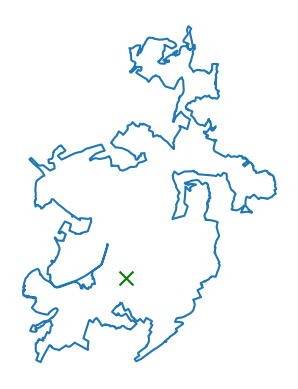

In [ ]:
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState, ArrivalTimeMatrixState
from fire_units.metrics import CoverIndexBuilding


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()
# state = ArrivalTimeMatrixState(matrix)

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция остановки
stop_case = lambda dynamic_nodes, **kwargs: len(dynamic_nodes) >= 1      # Расчет проводится для 1 подразделения

## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = state,
    matrix              = matrix,
    metric_function     = metric,
    stop_case_function  = stop_case,
)


# 3. Расчет BLP
best_nodes, best_metric = add(
        env          = G,
    )


# 4. Печать результатов
## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
ax = borders.boundary.plot()
g_nodes.loc[best_nodes.keys()].plot(ax=ax, color='green', marker='x', markersize=100)
ax.set_axis_off()
plt.show()

### Расчет с учетом имеющихся подразделений {.unnumbered}

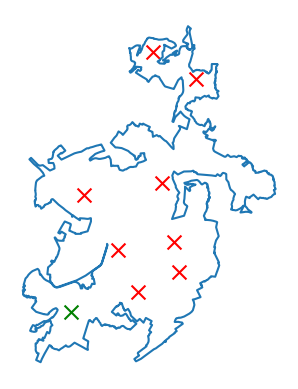

In [14]:
from genesis.lscp import LSCP_ADD
from genesis.states import FirstArrivalUnitState, ArrivalTimeMatrixState
from fire_units.metrics import CoverIndexBuilding, ArrivalTimeBuilding


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция остановки
stop_case = lambda dynamic_nodes, **kwargs: len(dynamic_nodes) >= 1      # Расчет проводится для 1 подразделения

## Сборка и инициализация алгоритма ADD
add = LSCP_ADD(  
    state_function      = state,
    matrix              = matrix,
    metric_function     = metric,
    stop_case_function  = stop_case,
)


# 3. Расчет BLP
best_nodes, best_metric = add(
        env          = G,
        static_nodes = units_dict,  # Размещение существующих подразделений пожарной охраны
    )


# 4. Печать результатов
## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
ax = borders.boundary.plot()
g_nodes.loc[best_nodes.keys()].plot(ax=ax, color='green', marker='x', markersize=100)
g_nodes.loc[units_dict.keys()].plot(ax=ax, color='red', marker='x', markersize=100)
ax.set_axis_off()
plt.show()

:::{.callout-important}
### Важно 

Алгоритм моделирования `ArrivalTimeMatrixState(matrix)` используется в `LSCP_ADD` только в том случае, если при расчете матрицы прибытия **не было указано** ограничение времени прибытия `cutoff`.

Если же в функции `get_atm` **было указано** ограничение времени прибытия `cutoff` (так как в примере выше), то следует использовать алгоритм моделирования `FirstArrivalUnitState()`

:::

## Дополнительные способы

### Полный перебор {.unnumbered}

Для небольших ГДС допустимо применение полного перебора всех узлов. Этот способ позволяет получить точное решение, в отличие от эвристических алгоритмов. Однако он требует значительных затрат времени.

|########################################| 100.0%


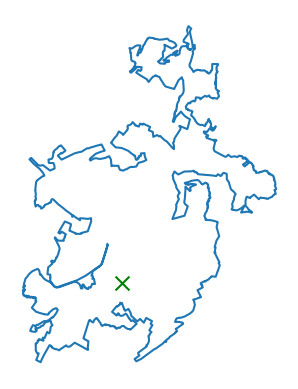

In [3]:
from genesis.best_points import BestNodesFull
from genesis.states import FirstArrivalUnitState
from fire_units.metrics import CoverIndexBuilding
from genesis.utils import Progressbar


# 1. Подготовка исходных данных
## Полный расчет слишком длителен, поэтому для примера работы
## выбираем 100 случайных узлов графа (для расчета за приемлемое время)
g_nodes_sample = ox.graph_to_gdfs(G, edges=False).sample(100)
g_nodes_sample = set(g_nodes_sample.index)


# 2. Сборка решения
## Выбор алгоритма моделирования параметров прибытия
state = FirstArrivalUnitState()
# state = ArrivalTimeMatrixState(matrix)

## Выбор метрики
metric = CoverIndexBuilding(buildings, ip_val=10) # Используется метрика ИП-10. Для ADD метрика выполняет роль оценки

## Функция выполняемая в конце расчета каждого узла. В данном случе - строка выполнения
node_calc_end = Progressbar(len(g_nodes_sample))

## Сборка и инициализация алгоритма полного перебора
full = BestNodesFull(
    state_function      = state,
    metric_function     = metric,
    node_calc_end_function = node_calc_end,
)



# 3. Расчет полным перебором узлов g_nodes_sample
best_nodes, best_metric = full(
        env          = G,
        points_list = g_nodes_sample,
    )


# 4. Печать результатов
## Получение набора данных узлов графа, для сопоставления с полученным лучшим узлом
g_nodes = ox.graph_to_gdfs(G, edges=False)

## Печать карты
ax = borders.boundary.plot()
g_nodes.loc[best_nodes.keys()].plot(ax=ax, color='green', marker='x', markersize=100)
ax.set_axis_off()
plt.show()